In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import LogLocator, NullFormatter
import struct

# import scienceplots
from tqdm import tqdm

# plt.style.use(['science','notebook','grid'])
jax.config.update("jax_enable_x64", True)

from scipy.fft import fftn,ifftn,fftshift
from numba import njit, prange, jit
from time import time
import sys,pathlib,os #, concurrent.futures

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
PI = np.pi
TWO_PI = 2*PI
N = 2**9

L = 2*PI

dx = L/N

shells = jnp.arange(-0.5,N//2+1,1)

# ---------------- Parameters ----------------
num_samples = 2**22  # total random pairs
p_orders = jnp.array([1.0], dtype=np.float64)
bins = jnp.linspace(0, N/2, N//2)  # radial bins

r = jnp.arange(0,512)*dx



""" If the number of vectors for a given r is more than 100000, we will keep randomly chosen 100000 of them"""
maxrhats = 100000 
maxcenters = 100000


X = Y =Z = jnp.linspace(0,TWO_PI,N,endpoint=False)
dx = dy = dz = X[1] - X[0]
x,y,z = jnp.meshgrid(X,Y,Z, indexing='ij')
idxs = jnp.arange(N)

vec = ((jnp.array(jnp.meshgrid(idxs,idxs,idxs,indexing='ij'))).astype(int) - N//2).reshape((3,N**3))
norms = jnp.linalg.norm(vec,axis=0)


centres = np.random.randint(0,N**3,(maxcenters))
newvecs = np.zeros((3,0))
cond = jnp.zeros((N**3,),dtype=bool)
cidx = jnp.zeros((maxrhats,),dtype=int)

centres.shape

(100000,)

In [4]:
# shell_radius = 40
# idx_shell_radius = jnp.array(np.where((norms >= shell_radius - 0.5) & (norms <= shell_radius + 0.5))[0])

# vec = vec[:,idx_shell_radius]
# norms = norms[idx_shell_radius]

# print('Total vectos in the shell:', idx_shell_radius.shape)

In [5]:
# u = jnp.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Homogeneous_Velocityfield_Real/Decimated_Homogeneous_P0p1.npz')['u_real']

# print("Velocity field:", u.shape)

In [6]:
import jax
import jax.numpy as jnp


@jax.jit
def sp_jax(u, vec, p, N, centres):
    """
    u       : (3, N, N, N)
    vec     : (3, Nvec)
    centres : (nc,)
    """

    Nvec = vec.shape[1]
    nc   = centres.shape[0]

    # Preallocate output
    data = jnp.zeros((Nvec, nc), dtype=jnp.float64)

    def outer_loop(ind1, data):
        sx = vec[0, ind1].astype(jnp.int32)
        sy = vec[1, ind1].astype(jnp.int32)
        sz = vec[2, ind1].astype(jnp.int32)

        norm = jnp.sqrt(sx*sx + sy*sy + sz*sz)
        inv  = 1.0 / norm

        rx = sx * inv
        ry = sy * inv
        rz = sz * inv

        def inner_loop(ii, data):
            c = centres[ii].astype(jnp.int32)

            ii1 =  c % N
            ii2 = (c // N) % N
            ii3 = (c // N) // N

            xip = (ii1 - sx) % N
            yip = (ii2 - sy) % N
            zip = (ii3 - sz) % N

            ux = u[0, ii1, ii2, ii3]-u[0, xip, yip, zip]  
            uy = u[1, ii1, ii2, ii3]-u[1, xip, yip, zip]  
            uz =  u[2, ii1, ii2, ii3]-u[2, xip, yip, zip] 

            proj = ux*rx + uy*ry + uz*rz

            return data.at[ind1, ii].set(proj)

        data = jax.lax.fori_loop(0, nc, inner_loop, data)
        return data

    data = jax.lax.fori_loop(0, Nvec, outer_loop, data)

    # Match original "flat append" behavior
    return data.reshape(-1)


In [7]:
# t1 = time()
# g = sp_jax(u,vec,p_orders,N,centres)
# t2 = time()

# print('The shape of g:', g.shape)
# print(f"Time taken = {t2 - t1:.2f} seconds")

In [14]:
def getPDF( field, nbins ):
        '''
        Outputs: 
                The normalized pdf of the input "field" over "nbins"
        '''
        field           = field.ravel()
        hist, bins      = np.histogram( field, bins = nbins )
        bins            = (bins[1:]+bins[:-1])*0.5
        pdf             = hist/(np.sum(hist)*np.mean(np.diff(bins)))

        return pdf, bins

# PDF , BINS =  getPDF(g, 1000)

In [20]:
mean_P0p0 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data'])
mean_P0p1 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data'])
mean_P0p3 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data'])
mean_P0p5 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data'])

In [6]:
std_P0p0 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data'])
std_P0p1 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data'])
std_P0p3 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data'])
std_P0p5 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data'])

In [7]:
third_mom_P0p0 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data']**3)
third_mom_P0p1 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data']**3)
third_mom_P0p3 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data']**3)
third_mom_P0p5 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data']**3)

In [8]:
fourth_mom_P0p0 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data']**4)
fourth_mom_P0p1 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data']**4)
fourth_mom_P0p3 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data']**4)
fourth_mom_P0p5 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data']**4)

In [9]:
sixth_mom_P0p0 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data']**6)
sixth_mom_P0p1 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data']**6)
sixth_mom_P0p3 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data']**6)
sixth_mom_P0p5 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data']**6)

In [16]:
PDF_P0p0 , BINS_P0p0 =  getPDF(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data'], 1000)

In [17]:
PDF_P0p5 , BINS_P0p5 =  getPDF(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data'], 1000)

In [18]:
PDF_P0p3 , BINS_P0p3 =  getPDF(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data'], 1000)

In [19]:
PDF_P0p1 , BINS_P0p1 =  getPDF(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data'], 1000)

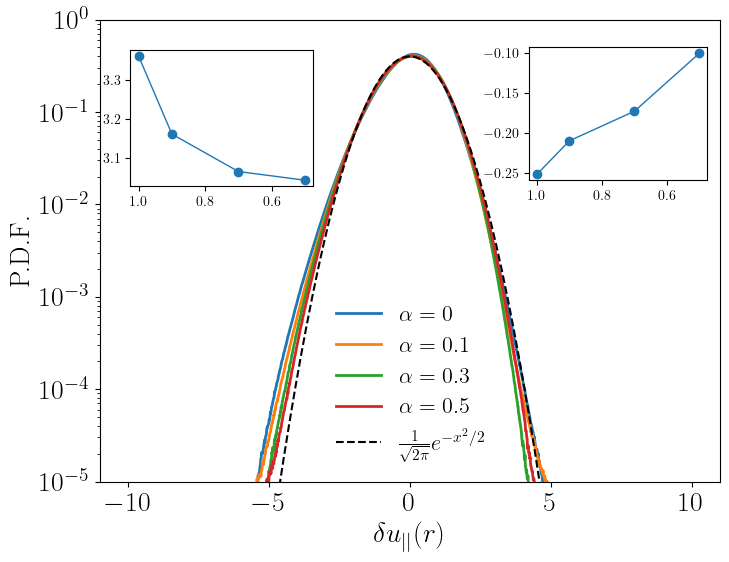

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20
})

# =========================
# Main figure
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

ax.semilogy(BINS_P0p0/std_P0p0, (PDF_P0p0 - mean_P0p0)*std_P0p0,
            lw=2, label=r'$\alpha = 0$')
ax.semilogy(BINS_P0p1/std_P0p1, (PDF_P0p1 - mean_P0p1)*std_P0p1,
            lw=2, label=r'$\alpha = 0.1$')
ax.semilogy(BINS_P0p3/std_P0p3, (PDF_P0p3 - mean_P0p3)*std_P0p3,
            lw=2, label=r'$\alpha = 0.3$')
ax.semilogy(BINS_P0p5/std_P0p5, (PDF_P0p5 - mean_P0p5)*std_P0p5,
            lw=2, label=r'$\alpha = 0.5$')

# Gaussian reference
ref_gauss_x = np.linspace(-10, 10, 200)
ax.semilogy(
    ref_gauss_x,
    (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * ref_gauss_x**2),
    '--', color='black', lw=1.5,
    label=r'$\frac{1}{\sqrt{2\pi}}e^{-x^2/2}$'
)

ax.set_ylim(1e-5, 1e0)
ax.set_xlabel(r'$\delta u_{||}(r)$')
ax.set_ylabel(r'P.D.F.')
ax.grid(False)

ax.legend(frameon=False, fontsize=16, loc="lower center")

# =========================
# Inset 1: Skewness
# =========================
axins1 = inset_axes(
    ax,
    width="36%",
    height="36%",
    bbox_to_anchor=(0.18, 0.14, 0.8, 0.8),  # (x0, y0, width, height)
    bbox_transform=ax.transAxes,
    borderpad=0
)


axins1.plot(alphas, skewness, 'o-',lw=1, ms = 6)

axins1.invert_xaxis()
axins1.tick_params(labelsize=10)
axins1.grid(False)

# =========================
# Inset 2: Kurtosis
# =========================
axins2 = inset_axes(
    ax,
    width="29.5%", height="29.5%",
    loc="upper left",
    borderpad=1.1
)

axins2.plot(alphas, kurtosis, 'o-',lw=1, ms = 6)

axins2.invert_xaxis()
axins2.tick_params(labelsize=10)
axins2.grid(False)
plt.savefig("delta_u_PDF.jpg", dpi = 300)
plt.show()


In [12]:
# np.savez("Inertial_vel_increaments_r40_P0p1", data = g)

In [10]:
alphas = np.array([1.0,0.9,0.7,0.5])

skewness = jnp.array([third_mom_P0p0/std_P0p0**3 ,third_mom_P0p1/std_P0p1**3 , third_mom_P0p3/std_P0p3**3,third_mom_P0p5/std_P0p5**3])

kurtosis = jnp.array([fourth_mom_P0p0/std_P0p0**4 ,fourth_mom_P0p1/std_P0p1**4 , fourth_mom_P0p3/std_P0p3**4,fourth_mom_P0p5/std_P0p5**4])

hyper_kurtosis = jnp.array([sixth_mom_P0p0/std_P0p0**6 ,sixth_mom_P0p1/std_P0p1**6 , sixth_mom_P0p3/std_P0p3**6,sixth_mom_P0p5/std_P0p5**6])

In [49]:
-(0.8 * 0.75 * 40 * dx)/(std_P0p0**3)

Array(-0.26893819, dtype=float64)

In [80]:
skewness[0]

Array(-0.2520092, dtype=float64)